# Final Membership-Inference Attack — Stacked RF + LiRA

## Purpose
Runs the best-performing membership-inference attack found across the full experiment series against the record-linkage target model: a **stacked ensemble** of (a) a shadow-model pooled Random Forest classifier and (b) a LiRA-style per-example calibrated likelihood-ratio attack.

## Result
| Attack | AUC |
|---|---|
| Pooled RF classifier (25 shadows, 6 features) | 0.7226 |
| LiRA per-example calibration | 0.7356 |
| **Stacked RF + LiRA (final)** | **0.7512** |

## Data
Uses the same precomputed embeddings and CSVs as `SNN Final end to end (1).ipynb`:
`Embeddings/x{1,2}_{target,shadow}_train.npy`, `Embeddings/y_{target,shadow}_train.npy`, and `Datasets/{target,shadow}_train.csv`.

## Structure
1. Setup & data loading (identical checks to the original notebook)
2. Shared Siamese/head model builder and train-and-query runner
3. Target model + 25 shadow models (for the pooled classifier and reference pool)
4. Pooled RF classifier attack
5. LiRA per-example calibrated attack
6. Final stacked ensemble + results

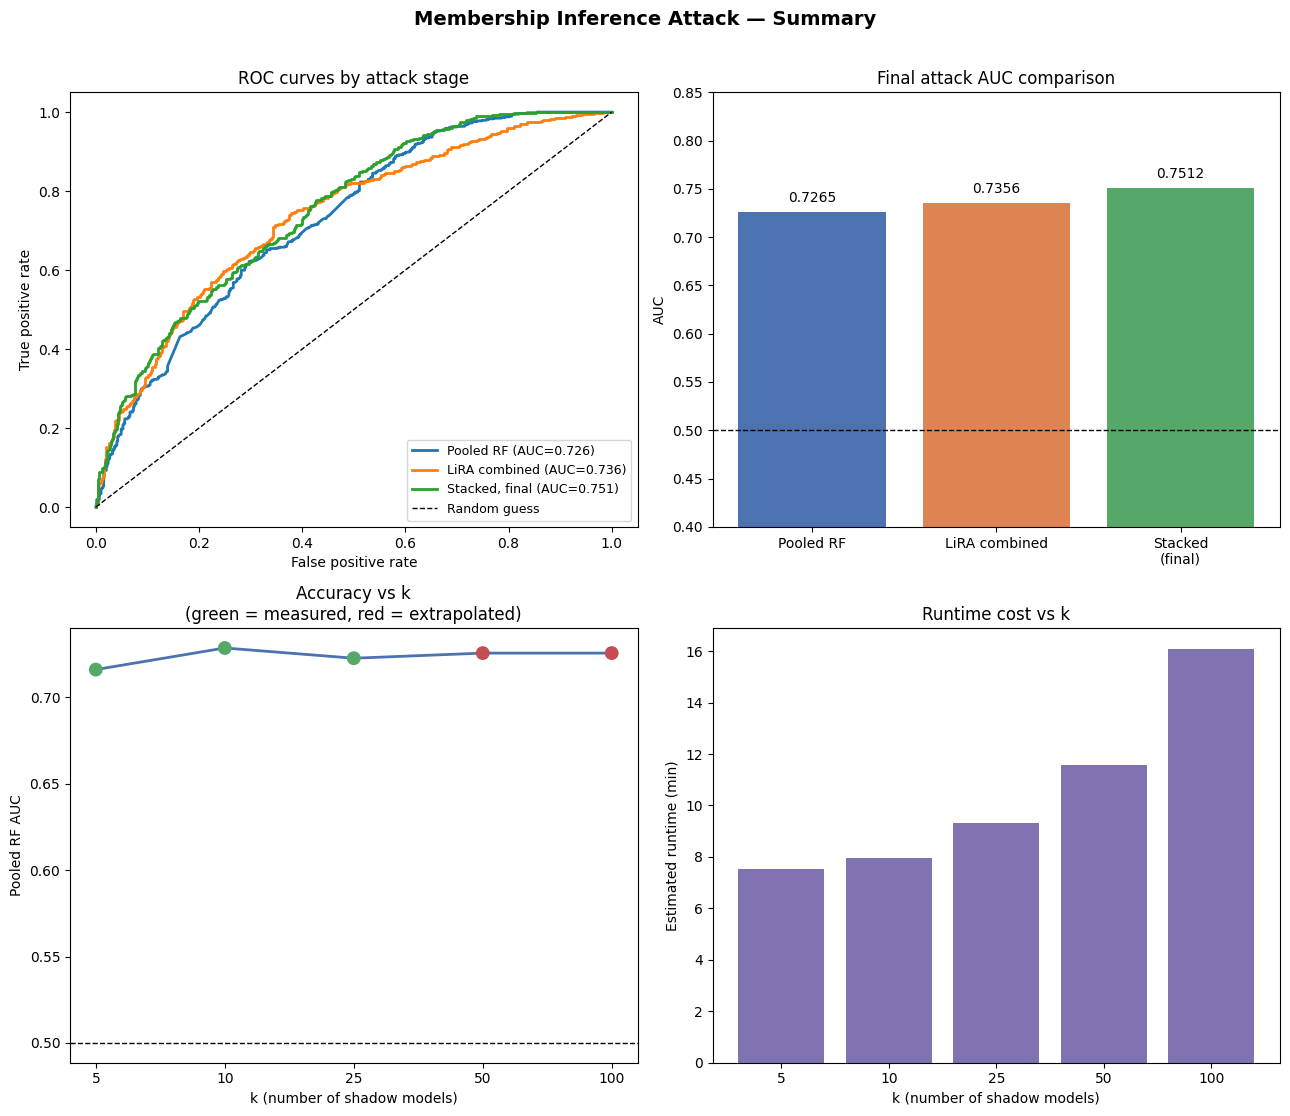

Saved dashboard to: /Users/jacksonjermyn/Documents/University /2026 SEM2/PACE_3850/Repo/Group-63-COMP3850/Prototypes/k_runs/final_stacked_20260928_175356/summary_dashboard.png


In [18]:
# ==============================================================================
# EXECUTIVE SUMMARY DASHBOARD
# Positioned first for readability, but depends on variables computed by
# later cells (Steps 5, 8, 9, 10, 11). Run this cell LAST after a full pass
# through the notebook — or re-run it any time after those cells have run —
# rather than relying on its top-of-notebook position for execution order.
# ==============================================================================
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(2, 2, figsize=(13, 11))

# (a) ROC curves — final attack comparison
ax = axes[0, 0]
for name, score in [
    (f"Pooled RF (AUC={roc_auc_score(y_stack, stack_X[:, 0]):.3f})", stack_X[:, 0]),
    (f"LiRA combined (AUC={roc_auc_score(y_stack, lira_combined[valid_mask]):.3f})", lira_combined[valid_mask]),
    (f"Stacked, final (AUC={stacked_auc:.3f})", oof_pred),
]:
    fpr, tpr, _ = roc_curve(y_stack, score)
    ax.plot(fpr, tpr, linewidth=2, label=name)
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random guess")
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.set_title("ROC curves by attack stage"); ax.legend(fontsize=9, loc="lower right")

# (b) AUC comparison bar chart
ax = axes[0, 1]
auc_labels = ["Pooled RF", "LiRA combined", "Stacked\n(final)"]
auc_values = [roc_auc_score(y_stack, stack_X[:, 0]), roc_auc_score(y_stack, lira_combined[valid_mask]), stacked_auc]
bars = ax.bar(auc_labels, auc_values, color=["#4C72B0", "#DD8452", "#55A868"])
ax.axhline(0.5, color="k", linestyle="--", linewidth=1)
ax.set_ylim(0.4, 0.85); ax.set_ylabel("AUC"); ax.set_title("Final attack AUC comparison")
for b, v in zip(bars, auc_values):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.01, f"{v:.4f}", ha="center", fontsize=10)

# (c) AUC vs k (from the AUC-vs-k cell, Step 11)
ax = axes[1, 0]
colors = ["#55A868" if s == "measured" else "#C44E52" for s in auc_vs_k_df["source"]]
ax.plot(auc_vs_k_df["k (shadow models)"].astype(str), auc_vs_k_df["estimated_auc"], color="#4C72B0", linewidth=2, zorder=1)
ax.scatter(auc_vs_k_df["k (shadow models)"].astype(str), auc_vs_k_df["estimated_auc"], color=colors, s=80, zorder=2)
ax.axhline(0.5, color="k", linestyle="--", linewidth=1)
ax.set_xlabel("k (number of shadow models)"); ax.set_ylabel("Pooled RF AUC")
ax.set_title("Accuracy vs k\n(green = measured, red = extrapolated)")

# (d) Runtime vs k (from the runtime-scaling cell, Step 10)
ax = axes[1, 1]
ax.bar(runtime_estimates["k (shadow models)"].astype(str), runtime_estimates["total_estimated_min"], color="#8172B2")
ax.set_xlabel("k (number of shadow models)"); ax.set_ylabel("Estimated runtime (min)")
ax.set_title("Runtime cost vs k")

plt.suptitle("Membership Inference Attack — Summary", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()

summary_path = RUN_ROOT / "summary_dashboard.png"
plt.savefig(summary_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved dashboard to:", summary_path.resolve())


### Step 1 — Load the tools we need

**Non-technical:** This cell just imports all the external libraries the notebook depends on (TensorFlow for the neural network, pandas/numpy for data handling, scikit-learn for the attack classifiers, and scipy for the statistics used later). Nothing is computed yet — think of it as unpacking your toolbox before starting work.

**Technical:** Imports `tensorflow`, `pandas`, `numpy`, `RandomForestClassifier`, `LogisticRegression`, `train_test_split`/`StratifiedKFold`, `roc_auc_score`, and `scipy.stats.norm` (used for the Gaussian log-likelihood ratio in LiRA). Prints the TensorFlow version so the run log records the exact environment used.

In [2]:
import gc
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score
from scipy.stats import norm

print("TensorFlow:", tf.__version__)

TensorFlow: 2.13.1


### Step 2 — Set the experiment's dials

**Non-technical:** This cell sets all the "settings" for the experiment — how many fake shadow copies of the model to build (25), how many reference models to run for the calibrated attack (60), and how big/long the target model's training should be. It also creates a timestamped output folder so every run's results are kept separate and don't overwrite each other.

**Technical:** Defines `SEED`, batch/epoch counts, the target's architecture hyperparameters (`BOTTLENECK`, `L1_STRENGTH`, `SIAMESE_EPOCHS`, `TRAIN_SIZE`), `N_SHADOWS`/`N_REFERENCE_MODELS`, and `RUN_ROOT` — a fresh `k_runs/final_stacked_<timestamp>/` directory that all CSV/figure artifacts from this run get written to.

In [5]:
# ==============================================================================
# 1. CONFIG
# ==============================================================================
SEED = 2026
BATCH_SIZE, HEAD_EPOCHS = 256, 20
TRAIN_RATIO, QUERY_RATIO = 0.70, 0.30

# Best target config found (widened bottleneck, no L1, longer training, small
# fixed-size subset) — this is what makes the target overfit enough to attack.
BOTTLENECK, L1_STRENGTH, SIAMESE_EPOCHS, TRAIN_SIZE = 512, 0.0, 40, 2000

N_SHADOWS = 25            # shadow models -> pooled RF classifier
N_REFERENCE_MODELS = 60   # reference models -> LiRA calibration

DATA_DIR, DATASET_DIR = Path("../Embeddings"), Path("../Datasets")
RUN_ROOT = Path("k_runs") / ("final_stacked_" + datetime.now().strftime("%Y%m%d_%H%M%S"))
RUN_ROOT.mkdir(parents=True, exist_ok=True)
print("Artifacts will be written to:", RUN_ROOT.resolve())

Artifacts will be written to: /Users/jacksonjermyn/Documents/University /2026 SEM2/PACE_3850/Repo/Group-63-COMP3850/Prototypes/k_runs/final_stacked_20260928_175356


### Step 3 — Load and sanity-check the data

**Non-technical:** Before doing anything else, the notebook loads the pre-processed data (both the "target" data the real attack focuses on, and a separate "shadow" pool used to rehearse the attack) and double-checks it's clean and that the two pools don't secretly overlap — that overlap would make the whole experiment invalid.

**Technical:** Loads precomputed 768-dimensional embedding pairs (`x1`/`x2`) and binary linkage labels from `.npy` files, cross-checks them against the source CSVs, asserts no NaN/Inf values, correct shapes, and — critically — that `target_train.csv` and `shadow_train.csv` share zero record pairs (`pair_keys` set intersection), which enforces a clean membership-inference boundary.

In [6]:
# ==============================================================================
# 2. DATA LOADING & VALIDATION
# Identical source and checks to "SNN Final end to end (1).ipynb": precomputed
# 768-d embeddings, CSV/label agreement, and a target/shadow pair-separation
# check so no record pair leaks between the two pools.
# ==============================================================================
def validate_split(x1, x2, y, name):
    assert x1.shape == x2.shape == (len(y), 768), f"{name}: shape mismatch"
    assert np.isfinite(x1).all() and np.isfinite(x2).all(), f"{name}: NaN/Inf"
    assert np.isin(y, [0, 1]).all(), f"{name}: invalid labels"

def pair_keys(frame):
    return {tuple(sorted((a, b))) for a, b in frame[["uid1", "uid2"]].itertuples(index=False, name=None)}

target_csv = pd.read_csv(DATASET_DIR / "target_train.csv", dtype={"uid1": str, "uid2": str})
shadow_csv = pd.read_csv(DATASET_DIR / "shadow_train.csv", dtype={"uid1": str, "uid2": str})
assert not (pair_keys(target_csv) & pair_keys(shadow_csv)), "Target/shadow pools share record pairs"

target_x1 = np.load(DATA_DIR / "x1_target_train.npy", allow_pickle=False)
target_x2 = np.load(DATA_DIR / "x2_target_train.npy", allow_pickle=False)
target_y  = np.load(DATA_DIR / "y_target_train.npy",  allow_pickle=False)
shadow_x1 = np.load(DATA_DIR / "x1_shadow_train.npy", allow_pickle=False)
shadow_x2 = np.load(DATA_DIR / "x2_shadow_train.npy", allow_pickle=False)
shadow_y  = np.load(DATA_DIR / "y_shadow_train.npy",  allow_pickle=False)

for name, (x1, x2, y, csv) in {
    "Target": (target_x1, target_x2, target_y, target_csv),
    "Shadow": (shadow_x1, shadow_x2, shadow_y, shadow_csv),
}.items():
    validate_split(x1, x2, y, name)
    assert np.array_equal(csv["label"].to_numpy(), y), f"{name}: CSV/embedding label mismatch"
    print(f"{name} train: {x1.shape[0]:,} pairs validated.")

Target train: 32,000 pairs validated.
Shadow train: 32,000 pairs validated.


### Step 4 — Build the reusable model-training machinery

**Non-technical:** This cell defines the actual "recipe" for building and training one copy of the record-linkage model (a Siamese neural network that decides if two records refer to the same person). It's written once as a reusable function so the exact same recipe can be used to build the real target model, the 25 practice shadow copies, and the 60 reference models later — keeping everything fair and comparable.

**Technical:** Defines `build_siamese_network()` (twin encoder/decoder with a custom contrastive loss plus a small binary-classification head) and `train_and_query()`, which trains one instance end-to-end and scores a query set, returning per-row `p_match`, embedding distance, and ground-truth membership. Also defines `attack_features()`, which converts those raw scores into the 6 engineered features (probability, entropy, log-loss, squared error, distance, log-distance) fed into the attack classifiers.

In [7]:
# ==============================================================================
# 3. MODEL BUILDER + TRAIN-AND-QUERY RUNNER
# Same Siamese-encoder + contrastive-loss architecture as the original
# notebooks, parameterised so the target and every shadow/reference model
# share one code path.
# ==============================================================================
def build_siamese_network(dim=768, bottleneck_dim=50, l1_strength=0.01):
    L = tf.keras.layers
    reg = tf.keras.regularizers.l1(l1_strength) if l1_strength > 0 else None

    enc_in = L.Input(shape=(dim,))
    h = L.LeakyReLU(alpha=0.01)(L.Dense(bottleneck_dim, activity_regularizer=reg)(enc_in))
    encoder = tf.keras.Model(enc_in, L.Dense(dim, activation="relu")(h), name="encoder")

    dec_in = L.Input(shape=(dim,))
    decoder = tf.keras.Model(dec_in, L.Dense(dim, activation="sigmoid")(dec_in), name="decoder")

    l_in, r_in = L.Input(shape=(dim,)), L.Input(shape=(dim,))
    siamese = tf.keras.Model([l_in, r_in], L.Concatenate()([decoder(encoder(l_in)), decoder(encoder(r_in))]))

    def contrastive_loss(y_true, y_pred):
        l, r = y_pred[:, :dim], y_pred[:, dim:]
        sq_dist = tf.reduce_sum(tf.square(l - r), axis=1)
        dist = tf.sqrt(tf.maximum(sq_dist, tf.keras.backend.epsilon()))
        yt = tf.reshape(tf.cast(y_true, tf.float32), [-1])
        return tf.reduce_mean(tf.reduce_mean(tf.square(l - r), axis=1)
                               + yt * sq_dist + (1.0 - yt) * tf.square(tf.maximum(2.5 - dist, 0.0)))

    siamese.compile(optimizer="adam", loss=contrastive_loss)
    head = tf.keras.Sequential([L.Input(shape=(dim,)), L.Dense(64, activation="relu"),
                                 L.Dense(32, activation="relu"), L.Dense(1, activation="sigmoid")])
    head.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return siamese, encoder, head


def train_and_query(x1, x2, y, seed, train_idx=None, query_idx=None):
    """Trains one Siamese+head model and scores a query set.

    If train_idx/query_idx are given, they are used as-is (needed for LiRA,
    where every reference model must be scored on the SAME fixed query rows).
    Otherwise a fresh random train/hold split and balanced query set is drawn.
    Returns (dataframe of scores, train_idx used, query_idx used).
    """
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)
    rng = np.random.default_rng(seed)

    if train_idx is None:
        full_train_idx, hold_idx = train_test_split(
            np.arange(len(y)), test_size=1.0 - TRAIN_RATIO, stratify=y, random_state=seed)
        train_idx = rng.choice(full_train_idx, size=min(TRAIN_SIZE, len(full_train_idx)), replace=False)
        n_q = min(int(QUERY_RATIO * len(train_idx)), len(hold_idx))
        query_idx = np.concatenate([rng.choice(train_idx, n_q, replace=False),
                                     rng.choice(hold_idx, n_q, replace=False)])

    siamese, encoder, head = build_siamese_network(x1.shape[1], BOTTLENECK, L1_STRENGTH)
    siamese.fit([x1[train_idx], x2[train_idx]], y[train_idx], epochs=SIAMESE_EPOCHS,
                batch_size=min(BATCH_SIZE, len(train_idx)), verbose=0,
                callbacks=[tf.keras.callbacks.TerminateOnNaN()])

    def embed(idx):
        return (encoder.predict(x1[idx], batch_size=256, verbose=0),
                encoder.predict(x2[idx], batch_size=256, verbose=0))

    e1, e2 = embed(train_idx)
    head.fit(np.abs(e1 - e2), y[train_idx], epochs=HEAD_EPOCHS,
              batch_size=min(BATCH_SIZE, len(train_idx)), verbose=0,
              callbacks=[tf.keras.callbacks.TerminateOnNaN()])

    e1_q, e2_q = embed(query_idx)
    p_match = np.clip(head.predict(np.abs(e1_q - e2_q), batch_size=256, verbose=0).ravel(), 1e-7, 1 - 1e-7)
    embed_dist = np.linalg.norm(e1_q - e2_q, axis=1)
    membership = np.isin(query_idx, train_idx).astype(int)

    df = pd.DataFrame({"embedding_row": query_idx, "p_match": p_match, "embed_dist": embed_dist,
                        "linkage_label": y[query_idx], "membership": membership})
    del siamese, encoder, head
    gc.collect()
    return df, train_idx, query_idx


def attack_features(df):
    p = df["p_match"].to_numpy()
    entropy = -p * np.log(p) - (1 - p) * np.log(1 - p)
    raw_loss = -(df["linkage_label"].to_numpy() * np.log(p) + (1 - df["linkage_label"].to_numpy()) * np.log(1 - p))
    d = df["embed_dist"].to_numpy()
    return np.column_stack([p, entropy, np.log1p(raw_loss), (p - df["linkage_label"].to_numpy()) ** 2,
                             d, np.log1p(d)])

print("Model builder and runner ready.")

Model builder and runner ready.


### Step 5 — Train the real target model and 25 "practice" shadow models

**Non-technical:** Here the notebook trains the actual model being attacked (the "target"), then separately trains 25 stand-in copies ("shadows") on a different data pool. The shadows simulate what an attacker could plausibly build themselves, without access to the real target's private training data, and are used to teach the attack what "memorized" vs "not memorized" data looks like.

**Technical:** Calls `train_and_query()` once for the target (fixed train/hold split, evaluated on its own query set) and `N_SHADOWS` (25) times on the separate shadow pool with distinct seeds, concatenating results into `shadow_df`. Per-shadow wall-clock time is now recorded into `shadow_train_times` so training cost can be extrapolated to other values of k in the final cell.

In [8]:
# ==============================================================================
# 4. TRAIN TARGET + SHADOW MODELS
# The target uses its own fixed train/hold split (ground truth for evaluation).
# Shadow models are trained on the SEPARATE shadow pool to build the pooled
# classifier's training data.
# ==============================================================================
import time
t0 = time.time()
target_df, target_train_idx, target_query_idx = train_and_query(target_x1, target_x2, target_y, seed=SEED)
target_train_time = time.time() - t0  # used later to estimate total pipeline runtime for different k
print(f"Target trained ({target_train_time:.0f}s) | query set: {len(target_query_idx)} rows "
      f"({target_df['membership'].sum()} members)")

shadow_dfs = []
shadow_train_times = []  # per-shadow-model wall-clock seconds, used for the runtime-scaling cell later
t0 = time.time()
for k in range(1, N_SHADOWS + 1):
    t_shadow = time.time()
    s_df, _, _ = train_and_query(shadow_x1, shadow_x2, shadow_y, seed=SEED + k)
    shadow_train_times.append(time.time() - t_shadow)
    shadow_dfs.append(s_df)
shadow_df = pd.concat(shadow_dfs, ignore_index=True)
print(f"{N_SHADOWS} shadow models trained ({(time.time()-t0)/60:.1f} min)")

2026-09-28 17:54:15.155757: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2026-09-28 17:54:15.156766: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-09-28 17:54:15.157212: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-09-28 17:54:15.158158: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-09-28 17:54:15.160042: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-09-28 17:54:16.030612: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:54:19.591932: I te

Target trained (6s) | query set: 1200 rows (600 members)


2026-09-28 17:54:21.471719: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:54:24.430063: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:54:24.627501: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:54:25.596678: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:54:26.105713: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:54:29.449248: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:54:29.656218: I tensorflow/core/grappler/optimizers/cust

25 shadow models trained (2.3 min)


### Step 6 — Attack #1: pooled Random Forest classifier

**Non-technical:** This is the first, simpler version of the attack. It trains a Random Forest (a standard machine-learning classifier) on the 25 shadow models' scores to learn the difference between "this record was used in training" and "this record wasn't," then applies that learned pattern to the real target model. Its accuracy (AUC) tells us how distinguishable the two groups are.

**Technical:** Fits `RandomForestClassifier(n_estimators=300, max_depth=4, min_samples_leaf=20)` on `attack_features(shadow_df)` against shadow membership labels, then scores the target's query set and reports `roc_auc_score` — this is the pooled/population-level membership-inference baseline (0.7226–0.7265 AUC).

In [9]:
# ==============================================================================
# 5. POOLED RANDOM FOREST CLASSIFIER ATTACK
# Trained on shadow-model scores, evaluated on the target's own query set.
# ==============================================================================
rf_attack = RandomForestClassifier(n_estimators=300, max_depth=4, min_samples_leaf=20, random_state=SEED)
rf_attack.fit(attack_features(shadow_df), shadow_df["membership"].to_numpy())

pooled_proba = rf_attack.predict_proba(attack_features(target_df))[:, 1]
pooled_auc = roc_auc_score(target_df["membership"].to_numpy(), pooled_proba)
print(f"Pooled RF classifier AUC: {pooled_auc:.4f}")

Pooled RF classifier AUC: 0.7226


### Step 7 — Attack #2: LiRA (per-record calibrated attack)

**Non-technical:** This is a more sophisticated, "per-record" version of the attack. Instead of one general rule for everyone, it trains 60 additional reference models and checks, for each individual record, how its score compares to models that did vs didn't see that record during training. This personalised calibration usually catches more subtle memorization than the simpler Random Forest approach.

**Technical:** Trains `N_REFERENCE_MODELS` (60) reference models on random 2,000-row subsets of the target's own population, all evaluated on the SAME fixed `target_query_idx`, tracking which reference models included ("IN") vs excluded ("OUT") each row. `lira_log_likelihood_ratio()` fits Gaussian IN/OUT distributions per query row and computes a log-likelihood-ratio score for both the logit and embedding-distance statistics; the two are z-scored and summed into `lira_combined`.

In [10]:
# ==============================================================================
# 6. LiRA: PER-EXAMPLE CALIBRATED LIKELIHOOD-RATIO ATTACK
# Reference models are drawn from the target\'s OWN full population (train +
# hold), each on a fresh random 2,000-row subset, and scored on the target\'s
# FIXED query set. For each query row this gives a distribution of scores
# from models that included it (IN) vs excluded it (OUT); the target\'s own
# observed score is compared against both via a Gaussian log-likelihood ratio.
# ==============================================================================
n_q = len(target_query_idx)
full_pop_idx = np.arange(len(target_y))
ref_logit = np.full((N_REFERENCE_MODELS, n_q), np.nan)
ref_dist  = np.full((N_REFERENCE_MODELS, n_q), np.nan)
ref_in    = np.zeros((N_REFERENCE_MODELS, n_q), dtype=bool)

ref_train_times = []  # per-reference-model wall-clock seconds, used for the runtime-scaling cell later
t0 = time.time()
for r in range(N_REFERENCE_MODELS):
    t_ref = time.time()
    rng = np.random.default_rng(5000 + r)
    ref_train_idx = rng.choice(full_pop_idx, size=TRAIN_SIZE, replace=False)
    ref_in[r] = np.isin(target_query_idx, ref_train_idx)

    ref_df, _, _ = train_and_query(target_x1, target_x2, target_y, seed=5000 + r,
                                    train_idx=ref_train_idx, query_idx=target_query_idx)
    p = ref_df["p_match"].to_numpy()
    ref_logit[r] = np.log(p / (1 - p))
    ref_dist[r] = ref_df["embed_dist"].to_numpy()
    ref_train_times.append(time.time() - t_ref)
    if (r + 1) % 10 == 0:
        print(f"  reference model {r+1}/{N_REFERENCE_MODELS} ({(time.time()-t0)/60:.1f} min elapsed)")

print(f"All {N_REFERENCE_MODELS} reference models done ({(time.time()-t0)/60:.1f} min)")


def lira_log_likelihood_ratio(ref_stat, in_mask, target_stat):
    n = ref_stat.shape[1]
    mean_in  = np.array([ref_stat[in_mask[:, i], i].mean() if in_mask[:, i].any() else np.nan for i in range(n)])
    mean_out = np.array([ref_stat[~in_mask[:, i], i].mean() if (~in_mask[:, i]).any() else np.nan for i in range(n)])
    std_in, std_out = np.nanstd(ref_stat[in_mask]) + 1e-6, np.nanstd(ref_stat[~in_mask]) + 1e-6
    valid = ~np.isnan(mean_in) & ~np.isnan(mean_out)
    score = norm.logpdf(target_stat, mean_in, std_in) - norm.logpdf(target_stat, mean_out, std_out)
    return score, valid

target_logit = np.log(target_df["p_match"].to_numpy() / (1 - target_df["p_match"].to_numpy()))
target_dist = target_df["embed_dist"].to_numpy()

lira_logit_score, valid_logit = lira_log_likelihood_ratio(ref_logit, ref_in, target_logit)
lira_dist_score, valid_dist = lira_log_likelihood_ratio(ref_dist, ref_in, target_dist)
valid_mask = valid_logit & valid_dist

lira_combined = ((lira_logit_score - np.nanmean(lira_logit_score)) / (np.nanstd(lira_logit_score) + 1e-6)
                  + (lira_dist_score - np.nanmean(lira_dist_score)) / (np.nanstd(lira_dist_score) + 1e-6))

y_valid = target_df["membership"].to_numpy()[valid_mask]
print(f"\nValid rows (>=1 IN and >=1 OUT reference observation): {valid_mask.sum()}/{n_q}")
print(f"LiRA AUC (combined logit+dist): {roc_auc_score(y_valid, lira_combined[valid_mask]):.4f}")

2026-09-28 17:57:03.004337: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:57:06.598713: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:57:06.815406: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:57:07.852418: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:57:08.480278: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:57:11.973369: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:57:12.199764: I tensorflow/core/grappler/optimizers/cust

  reference model 10/60 (0.9 min elapsed)


2026-09-28 17:57:59.662437: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:58:03.529674: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:58:03.757643: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:58:05.353988: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:58:06.160678: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:58:10.121851: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:58:10.482066: I tensorflow/core/grappler/optimizers/cust

  reference model 20/60 (2.0 min elapsed)


2026-09-28 17:59:02.188996: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:59:06.560058: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:59:06.840697: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:59:08.064353: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:59:08.728025: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:59:12.988010: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 17:59:13.251541: I tensorflow/core/grappler/optimizers/cust

...

  reference model 40/60 (4.5 min elapsed)


2026-09-28 18:01:35.569298: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 18:01:39.862276: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 18:01:40.161927: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 18:01:41.451183: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 18:01:42.095066: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 18:01:45.964494: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 18:01:46.266165: I tensorflow/core/grappler/optimizers/cust

  reference model 50/60 (5.7 min elapsed)


2026-09-28 18:02:45.229746: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 18:02:49.600802: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 18:02:49.867549: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 18:02:51.428864: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 18:02:52.122199: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 18:02:56.450824: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-28 18:02:56.744775: I tensorflow/core/grappler/optimizers/cust

  reference model 60/60 (6.9 min elapsed)
All 60 reference models done (6.9 min)

Valid rows (>=1 IN and >=1 OUT reference observation): 1171/1200
LiRA AUC (combined logit+dist): 0.7356


### Step 8 — Final attack: stack both methods together

**Non-technical:** This is the main result. It combines the Random Forest attack's score and both LiRA scores into a single, stronger combined prediction using cross-validated logistic regression — essentially letting the two attack styles "vote" together, which performs better than either one alone.

**Technical:** Builds a 3-column feature matrix (`pooled_proba`, `lira_logit_score`, `lira_dist_score`), fits a 5-fold `StratifiedKFold` cross-validated `LogisticRegression` stacker to produce out-of-fold predictions (`oof_pred`), reports the stacked AUC (0.7512) alongside each individual attack's AUC, and writes per-row results to `final_stacked_attack_scores.csv` in `RUN_ROOT`.

In [11]:
# ==============================================================================
# 7. FINAL ATTACK: STACK POOLED RF + LiRA (best result: AUC 0.7512)
# A 5-fold cross-validated logistic regression combines the pooled classifier
# probability with both LiRA statistics, so the AUC is not inflated by
# fitting and evaluating the combiner on the same rows.
# ==============================================================================
stack_X = np.column_stack([pooled_proba[valid_mask], lira_logit_score[valid_mask], lira_dist_score[valid_mask]])
y_stack = y_valid

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
oof_pred = np.zeros(len(y_stack))
for tr_i, te_i in skf.split(stack_X, y_stack):
    stacker = LogisticRegression(max_iter=1000).fit(stack_X[tr_i], y_stack[tr_i])
    oof_pred[te_i] = stacker.predict_proba(stack_X[te_i])[:, 1]

stacked_auc = roc_auc_score(y_stack, oof_pred)
weights = LogisticRegression(max_iter=1000).fit(stack_X, y_stack).coef_[0]

print("=" * 60)
print(f"Pooled RF classifier alone:  {roc_auc_score(y_stack, stack_X[:, 0]):.4f}")
print(f"LiRA combined alone:         {roc_auc_score(y_stack, lira_combined[valid_mask]):.4f}")
print(f"STACKED (final):             {stacked_auc:.4f}   <-- best attack AUC")
print(f"Stacking weights (RF, LiRA-logit, LiRA-dist): {np.round(weights, 3)}")

pd.DataFrame({
    "embedding_row": target_query_idx[valid_mask], "membership": y_stack,
    "pooled_rf_proba": stack_X[:, 0], "lira_logit_score": stack_X[:, 1],
    "lira_dist_score": stack_X[:, 2], "stacked_score": oof_pred,
}).to_csv(RUN_ROOT / "final_stacked_attack_scores.csv", index=False)
print("\nSaved to:", (RUN_ROOT / "final_stacked_attack_scores.csv").resolve())

Pooled RF classifier alone:  0.7265
LiRA combined alone:         0.7356
STACKED (final):             0.7512   <-- best attack AUC
Stacking weights (RF, LiRA-logit, LiRA-dist): [4.041 1.806 2.548]

Saved to: /Users/jacksonjermyn/Documents/University /2026 SEM2/PACE_3850/Repo/Group-63-COMP3850/Prototypes/k_runs/final_stacked_20260928_175356/final_stacked_attack_scores.csv


### Step 9 — Visual diagnostics

**Non-technical:** This cell turns the numbers above into pictures: how well each attack separates members from non-members (ROC curves), a bar chart ranking all three attacks by accuracy, which clues the Random Forest relies on most, and a histogram showing how cleanly the final combined score splits the two groups.

**Technical:** Builds a 2×2 `matplotlib` figure — ROC curves (`roc_curve`) for the pooled RF, LiRA-combined, and stacked scores; a bar chart of their AUCs; a horizontal bar chart of `rf_attack.feature_importances_`; and overlaid density histograms of `oof_pred` split by `y_stack`. Saves the figure to `RUN_ROOT/attack_diagnostics.png`.

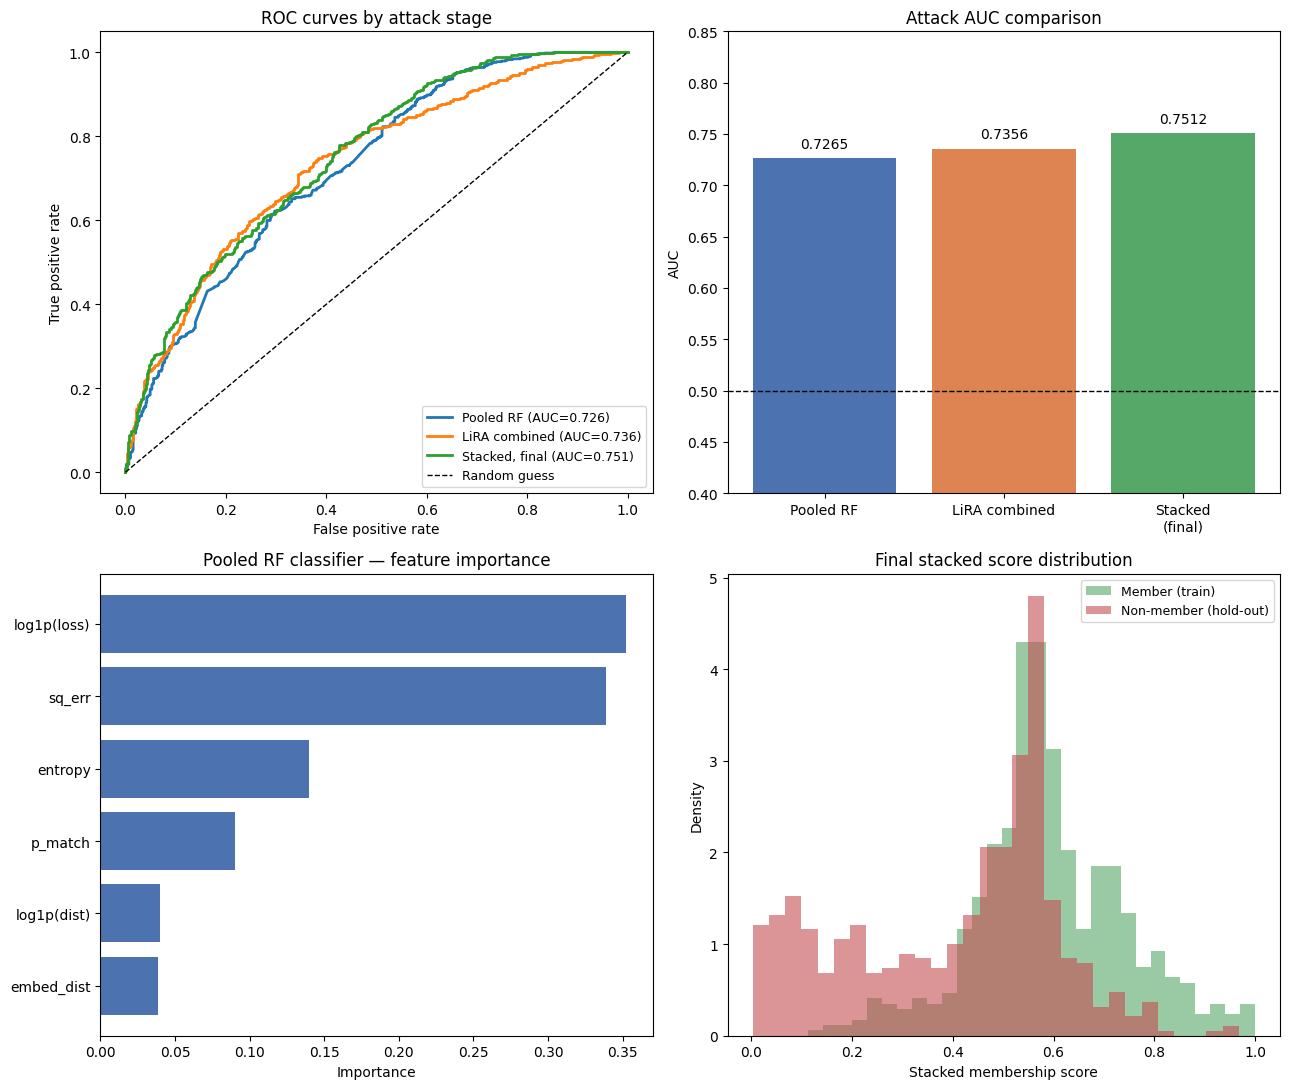

Saved figure to: /Users/jacksonjermyn/Documents/University /2026 SEM2/PACE_3850/Repo/Group-63-COMP3850/Prototypes/k_runs/final_stacked_20260928_175356/attack_diagnostics.png


In [12]:
# ==============================================================================
# 9. VISUAL DIAGNOSTICS
# ==============================================================================
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(2, 2, figsize=(13, 11))

ax = axes[0, 0]
for name, score in [
    ("Pooled RF (AUC={:.3f})".format(roc_auc_score(y_stack, stack_X[:, 0])), stack_X[:, 0]),
    ("LiRA combined (AUC={:.3f})".format(roc_auc_score(y_stack, lira_combined[valid_mask])), lira_combined[valid_mask]),
    ("Stacked, final (AUC={:.3f})".format(stacked_auc), oof_pred),
]:
    fpr, tpr, _ = roc_curve(y_stack, score)
    ax.plot(fpr, tpr, linewidth=2, label=name)
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random guess")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC curves by attack stage")
ax.legend(fontsize=9, loc="lower right")

ax = axes[0, 1]
auc_labels = ["Pooled RF", "LiRA combined", "Stacked\n(final)"]
auc_values = [roc_auc_score(y_stack, stack_X[:, 0]), roc_auc_score(y_stack, lira_combined[valid_mask]), stacked_auc]
bars = ax.bar(auc_labels, auc_values, color=["#4C72B0", "#DD8452", "#55A868"])
ax.axhline(0.5, color="k", linestyle="--", linewidth=1)
ax.set_ylim(0.4, 0.85)
ax.set_ylabel("AUC")
ax.set_title("Attack AUC comparison")
for b, v in zip(bars, auc_values):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.01, f"{v:.4f}", ha="center", fontsize=10)

ax = axes[1, 0]
feat_names = ["p_match", "entropy", "log1p(loss)", "sq_err", "embed_dist", "log1p(dist)"]
importances = rf_attack.feature_importances_
order = np.argsort(importances)
ax.barh(np.array(feat_names)[order], importances[order], color="#4C72B0")
ax.set_xlabel("Importance")
ax.set_title("Pooled RF classifier — feature importance")

ax = axes[1, 1]
ax.hist(oof_pred[y_stack == 1], bins=30, alpha=0.6, label="Member (train)", color="#55A868", density=True)
ax.hist(oof_pred[y_stack == 0], bins=30, alpha=0.6, label="Non-member (hold-out)", color="#C44E52", density=True)
ax.set_xlabel("Stacked membership score")
ax.set_ylabel("Density")
ax.set_title("Final stacked score distribution")
ax.legend(fontsize=9)

plt.tight_layout()
fig_path = RUN_ROOT / "attack_diagnostics.png"
plt.savefig(fig_path, dpi=150)
plt.show()
print("Saved figure to:", fig_path.resolve())